In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

import os
import pickle
from matplotlib.ticker import MaxNLocator, ScalarFormatter, FormatStrFormatter
from matplotlib.ticker import LinearLocator
FIGSIZE = (4.5,3)
DPI = 300
N_TICKS = 3

In [3]:
from src.discrimalign import discrimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [15]:
from miRBench.dataset import list_datasets, get_dataset_df

In [16]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [17]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### General matrix, affine gap penalty

In [18]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [19]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [20]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

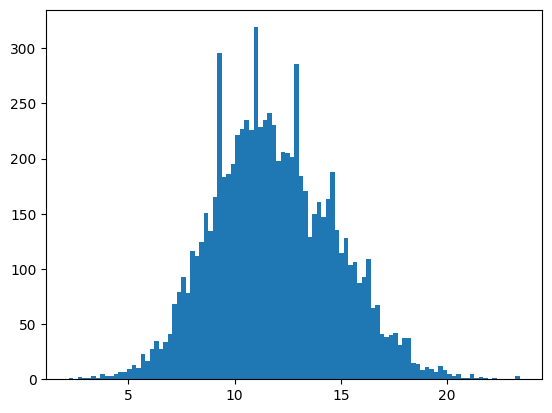

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [21]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

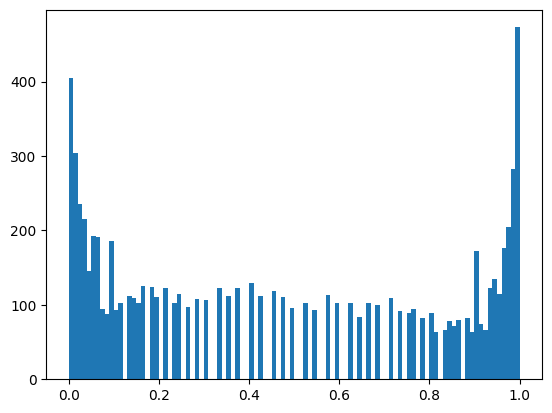

In [12]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [29]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2968.1308504149256


In [14]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [15]:
NITER = 200

In [ ]:
params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

In [17]:
print(params['final_loglik'])

-2931.755443027663


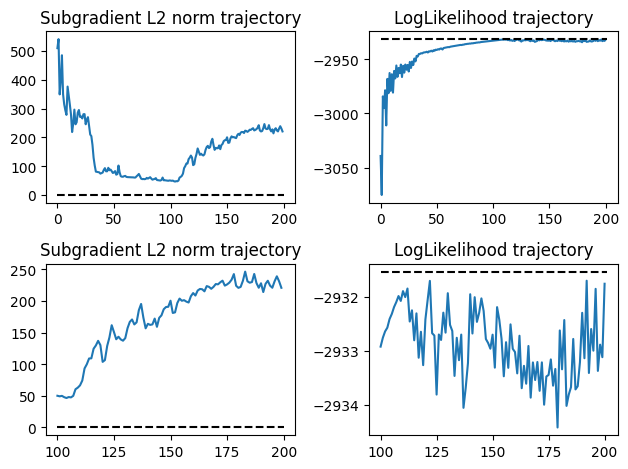

In [18]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector)))) # mean asolute error calculation vs correlation boxplot for 20 replicates (data already present) 

-1.2 -1.1851905329697283
-0.1 -0.10008519066004118
-12 -12.508575909332592
A A 1.0 1.0104810615788193
A C -0.3 -0.22698409597437372
A T -1.0 -0.8214807581847762
A G -0.8 -0.6561839939193942
C A -0.6 -0.48426625859883055
C C 1.2 1.2172779269001817
C T -0.3 -0.41717028239192755
C G -1.0 -0.8998356615237482
T A -1.2 -1.0434559189566939
T C -0.4 -0.3578481356855115
T T 1.0 1.026599951981614
T G -0.8 -0.7567804457349925
G A -0.4 -0.4718224804451187
G C -1.4 -1.056223528410227
G T -0.9 -0.8720294472245051
G G 1.3 1.311730936456145
[[1.         0.99427657]
 [0.99427657 1.        ]]
0.09249964972129707


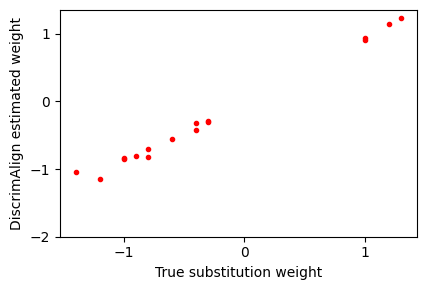

In [48]:
plt.figure(figsize=FIGSIZE)

plt.plot(true_subs_vector, param_subs_vector, 'r.')

plt.xlabel("True substitution weight")
plt.ylabel("DiscrimAlign estimated weight")

plt.tight_layout()
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(-2, 1, 4))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))
plt.savefig("results/general/true_vs_estimated_submatrix.png", dpi=DPI)

In [21]:
from src.optimization import get_initial_estimate

In [22]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': np.float64(-12.682524776500578),
 'substitution_matrix': Array([[ 1.03658738, -0.21717569, -0.92129275, -0.68208361],
        [-0.4713911 ,  1.24322242, -0.42008332, -1.03595458],
        [-1.1596995 , -0.37145556,  1.05582003, -0.79676399],
        [-0.48423113, -1.35230841, -0.97960697,  1.34063997]],
          alphabet='ACTG'),
 'open_gap_score': np.float64(-1.2177512774567372),
 'extend_gap_score': np.float64(-0.09605980120352103)}

In [23]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [24]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [25]:
estim_substitution

Array([[ 1.01048106, -0.2269841 , -0.82148076, -0.65618399],
       [-0.48426626,  1.21727793, -0.41717028, -0.89983566],
       [-1.04345592, -0.35784814,  1.02659995, -0.75678045],
       [-0.47182248, -1.05622353, -0.87202945,  1.31173094]],
         alphabet='ACTG')

### Step function parameters experiment

In [49]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [50]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [51]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [52]:
NITER = 200

In [53]:
# Get the iteration at which logL is hit (speed)
def get_logL__reached_iter(params, true_logL):
    for i, logL in enumerate(params['loglik_trajectory']):
        if logL >= true_logL:
            return i
    return None

In [54]:
# Get the value at the last iteration of the simulation
def get_final_val_avg(params):
    return np.mean(params['loglik_trajectory'][-20:])

In [55]:
pickle_path = "results/general/step_experiment_general.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    labels = saved["labels"]
    true_logL = saved["true_logL"]
    discrimalign_results_step = saved["discrimalign_results_step"]
    logL_reached_iters = saved["logL_reached_iters"]
    final_vals = saved["final_vals"]

else:
    
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    
    discrimalign_results_step = []

    logL_reached_iters = []
    final_vals = []

    for stepl in steplengths:
        const_step = create_constant_step(stepl)
        
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='general', ## changed 
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_step.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        logL_reached_iters.append(logL_reached_iter if logL_reached_iter is not None else np.inf) # infinity so that they dont show on the scatter plot 

        final_val = get_final_val_avg(params)
        final_vals.append(final_val)

        if logL_reached_iter is not None:
            print(f"step {stepl:.2e}, surpassed logL at iteration {logL_reached_iter} and reached a maximum value of {final_val}")
        else:
            print(f"step {stepl:.2e} did NOT hit logL")
    
    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "labels": labels,
                "true_logL": true_logL,
                "discrimalign_results_step": discrimalign_results_step,
                "logL_reached_iters": logL_reached_iters,
                "final_vals": final_vals,
                "steplengths": steplengths,
                "NITER": NITER,
            },
            f
        )

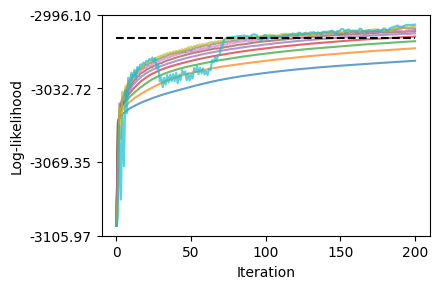

In [56]:
step_colors = plt.cm.tab10(np.linspace(0, 1, len(steplengths)))

plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("results/general/step_experiment_full_trajectories_general.png", dpi=DPI)

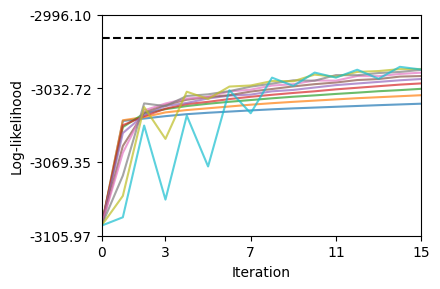

In [57]:
# zoom on start
plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlim(0, 15)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
ax.set_xticks(np.linspace(0, 15, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("results/general/step_experiment_zoom_start_general.png", dpi=DPI)

In [58]:
# # zoom where most trajectories hit logL
# plt.figure(figsize=FIGSIZE)
# for params,color in zip(discrimalign_results_step, step_colors):
#     plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
# plt.plot([0, NITER], [true_logL, true_logL], 'k--')

# plt.xlim(25, NITER) 
# all_vals = np.concatenate([
#     np.array(p['loglik_trajectory'])[25:]
#     for p in discrimalign_results_step
# ])

# ymin, ymax = all_vals.min(), all_vals.max()
# plt.ylim(ymin, 0.9999 * ymax)
# plt.xlabel("Iteration")
# plt.ylabel("Log-likelihood")

# ax = plt.gca()
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.tight_layout()
# plt.savefig("results/general/step_experiment_zoom_mid_general.png", dpi=DPI)

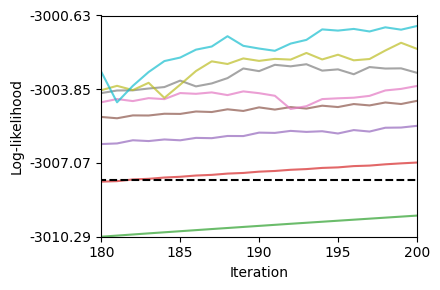

In [59]:
# zoom on the end of the iterations
plt.figure(figsize=FIGSIZE)

for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
    
plt.plot([0, NITER], [true_logL, true_logL], 'k--')


plt.xlim(NITER-20, NITER)

# collect only last 20 iterations
all_vals = np.concatenate([
    np.array(p['loglik_trajectory'])[NITER-20:]
    for p in discrimalign_results_step
])

#sort and drop lowest x % 
sorted_vals = np.sort(all_vals)
cutoff = int(0.2 * len(sorted_vals))  # remove lowest x%
trimmed_vals = sorted_vals[cutoff:]

ymin = trimmed_vals.min()
ymax = trimmed_vals.max()

pad = 0.05 * (ymax - ymin)

plt.ylim(ymin, ymax + pad)

ax = plt.gca()
ax.set_xticks(np.linspace(180, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

plt.tight_layout()
plt.savefig("results/general/step_experiment_zoom_end_general.png", dpi=DPI)

/tmp/ipykernel_50373/1231280037.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_steps))


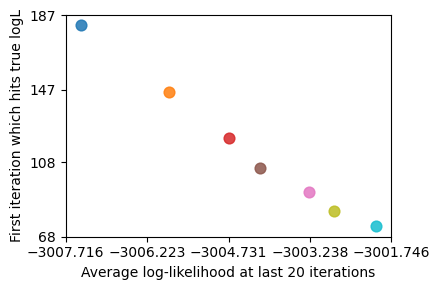

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter


plt.figure(figsize=FIGSIZE)

logL_reached_iters_arr = np.array(logL_reached_iters)
final_vals_arr = np.array(final_vals)
steplengths_arr = np.array(steplengths)

mask = np.isfinite(logL_reached_iters_arr)

# Get unique step sizes
unique_steps = np.sort(np.unique(steplengths_arr[mask]))

# Use a discrete colormap
cmap = plt.cm.get_cmap("tab10", len(unique_steps))

for i, s in enumerate(unique_steps):
    idx = (steplengths_arr == s) & mask

    plt.scatter(
        final_vals_arr[idx],
        logL_reached_iters_arr[idx],
        color=cmap(i),
        s=60,
        label=f"{s:.2e}",
        alpha=0.85
    )

plt.ylabel("First iteration which hits true logL")
plt.xlabel("Average log-likelihood at last 20 iterations")


ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(xmin, xmax, 5))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/general/step_experiment_scatter_hit_vs_final_general.png", dpi=DPI)

### Replicates

In [61]:
REPS = 20 #20
NITER = 200

In [62]:
const_step = create_constant_step(4.0e-05) # choose best step from prev exp 
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [63]:
# Checks if the chosen step size is stable in convergence across different datasets
pickle_path = "results/general/replicates_general.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    discrimalign_results_rep = saved["discrimalign_results_rep"]
    true_logLs = saved["true_logLs"]
    logL_reached_iters_rep = saved["logL_reached_iters_rep"]
    final_vals_rep = saved["final_vals_rep"]

else:

    discrimalign_results_rep = []
    true_logLs = []

    logL_reached_iters_rep = []
    final_vals_rep = []

    for _ in range(REPS):
        labels = rd.rand(len(mirlist)) <= logit_scores
        true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
        true_logLs.append(true_logL)
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='general', ## changed
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_rep.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        
        logL_reached_iters_rep.append(
            logL_reached_iter if logL_reached_iter is not None else np.inf
        )

        final_vals_rep.append(get_final_val_avg(params))

    for i, it in enumerate(logL_reached_iters_rep):
        if np.isfinite(it):
            print(f"rep {i} hit logL at iteration {it}, final={final_vals_rep[i]:.2f}")
        else:
            print(f"rep {i} did NOT hit logL, final={final_vals_rep[i]:.2f}")

    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "discrimalign_results_rep": discrimalign_results_rep,
                "true_logLs": true_logLs,
                "logL_reached_iters_rep": logL_reached_iters_rep,
                "final_vals_rep": final_vals_rep,
                "REPS": REPS,
                "NITER": NITER,
            },
            f
        )

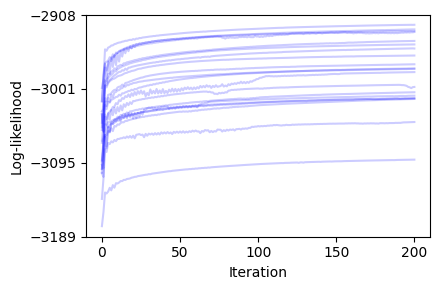

In [64]:
plt.figure(figsize=FIGSIZE)

for params in discrimalign_results_rep:
    plt.plot(
        np.arange(NITER + 1),
        params['loglik_trajectory'],
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

ax = plt.gca()

xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/general/replicates_loglik_trajectories_general.png", dpi=DPI)

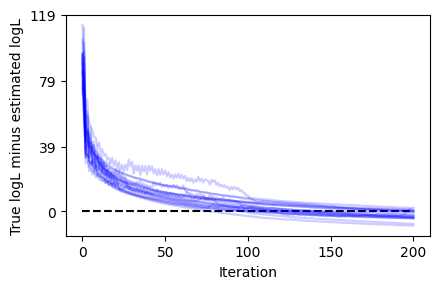

In [65]:
plt.figure(figsize=FIGSIZE)

plt.plot([0, NITER], [0, 0], 'k--')

for params, tlL in zip(discrimalign_results_rep, true_logLs):
    plt.plot(
        np.arange(NITER + 1),
        tlL - np.array(params['loglik_trajectory']),
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("True logL minus estimated logL")

ax = plt.gca()

xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_xlim(xmin, xmax)


ymin, ymax = ax.get_ylim()
ax.set_yticks(np.linspace(0, ymax+1, 4, dtype=int))
plt.tight_layout()
plt.savefig("results/general/replicates_loglik_gap_general.png", dpi=DPI)

In [66]:
rep_corrs = []
rep_maes = []

for params in discrimalign_results_rep:
    print(true_gapopen, params['open_gap_score'])
    print(true_gapext, params['extend_gap_score'])
    print(true_alpha, params['alpha'])

    true_subs_vector = []
    param_subs_vector = []

    for char1 in true_substitution.alphabet:
        for char2 in true_substitution.alphabet:
            true_v = true_substitution[char1, char2]
            estim_v = params['substitution_matrix'][char1, char2]

            true_subs_vector.append(true_v)
            param_subs_vector.append(estim_v)

            print(char1, char2, true_v, estim_v)

    true_subs_vector = np.array(true_subs_vector)
    param_subs_vector = np.array(param_subs_vector)

    corr = np.corrcoef(true_subs_vector, param_subs_vector)[0, 1]
    mae = np.mean(np.abs(true_subs_vector - param_subs_vector))

    print(np.corrcoef(true_subs_vector, param_subs_vector))
    print(mae)

    rep_corrs.append(corr)
    rep_maes.append(mae)

rep_corrs = np.array(rep_corrs)
rep_maes = np.array(rep_maes)

-1.2 -1.2372038118661783
-0.1 -0.0971217122795078
-12 -11.758288826696905
A A 1.0 0.9679770142015088
A C -0.3 -0.32798554508769556
A T -1.0 -1.0182532371313586
A G -0.8 -0.7553692578353035
C A -0.6 -0.6637291240323178
C C 1.2 1.187560283884012
C T -0.3 -0.2646349966121609
C G -1.0 -0.861989416966994
T A -1.2 -1.1255919811546542
T C -0.4 -0.42192992664949597
T T 1.0 1.0124477802684704
T G -0.8 -0.7756496887494916
G A -0.4 -0.47153171016868584
G C -1.4 -0.9806976700856151
G T -0.9 -0.8537582120852466
G G 1.3 1.2857596761865757
[[1.       0.992721]
 [0.992721 1.      ]]
0.06605557034852884
-1.2 -1.143513633916548
-0.1 -0.09485173239945481
-12 -11.739980947764192
A A 1.0 0.9899975623932752
A C -0.3 -0.24946845173817805
A T -1.0 -0.7989695733286434
A G -0.8 -0.6714257006473819
C A -0.6 -0.594469322229207
C C 1.2 1.1619412323296165
C T -0.3 -0.27552181636995154
C G -1.0 -0.9371000422467883
T A -1.2 -1.0001836847502663
T C -0.4 -0.42804590547072735
T T 1.0 0.958672037794885
T G -0.8 -0.743449

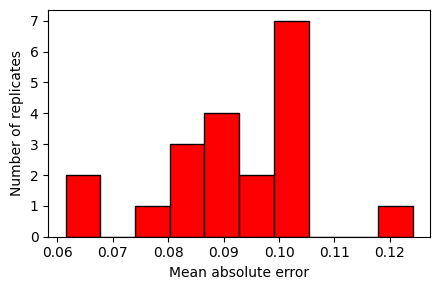

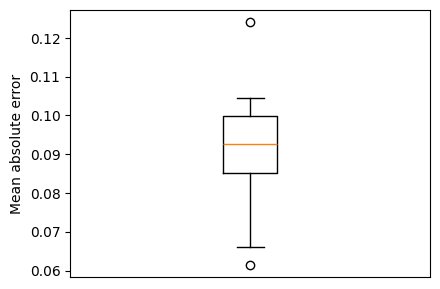

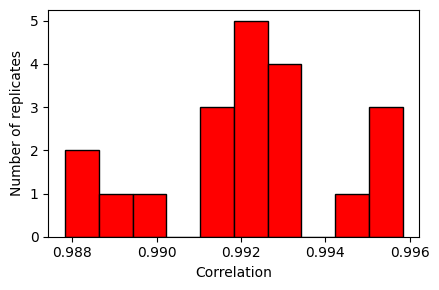

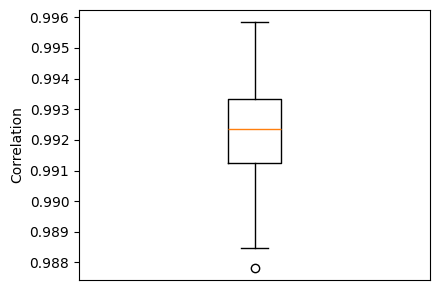

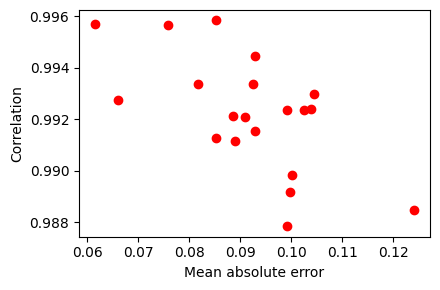

In [67]:
plt.figure(figsize=FIGSIZE)
plt.hist(rep_maes, bins=10, edgecolor = 'black', color = 'red')
plt.xlabel("Mean absolute error")
plt.ylabel("Number of replicates")
plt.tight_layout()
plt.savefig("results/general/replicates_mae_histogram_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.boxplot(rep_maes)
plt.ylabel("Mean absolute error")
plt.xticks([])
plt.tight_layout()
plt.savefig("results/general/replicates_mae_boxplot_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.hist(rep_corrs, bins=10, edgecolor = 'black', color = 'red')
plt.xlabel("Correlation")
plt.ylabel("Number of replicates")
plt.tight_layout()
plt.savefig("results/general/replicates_correlation_histogram_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.boxplot(rep_corrs)
plt.ylabel("Correlation")
plt.xticks([])
plt.tight_layout()
plt.savefig("results/general/replicates_correlation_boxplot_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.scatter(rep_maes, rep_corrs, color = 'red')
plt.xlabel("Mean absolute error")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig("results/general/replicates_mae_vs_correlation_scatter_general.png", dpi=DPI)
plt.show()